# Notebook 01: Data Loading & Cleaning

## Contexto

Este notebook carga los datos brutos del sistema de prospecting de **Raona** (Microsoft Gold Partner), 
crea la variable objetivo y guarda un dataset limpio en formato Parquet.

### Eleccion de la tabla base

El sistema HeyReach exporta dos tablas principales:

| Tabla | Granularidad | Filas | ID |
|-------|-------------|-------|----|
| `conversation_level_analytics_ES.csv` | Una fila por conversacion (campana x contacto) | 11,517 | `contactId` (numerico interno) |
| `contacts_table_ES.csv` | Una fila por contacto unico | 11,095 | `LinkedIn profile ID` |

**Problema:** El `contactId` de analytics es un ID interno de HeyReach que no existe en ninguna otra tabla exportada. 
El join directo entre analytics y contacts produce **0% de match**.

**Solucion:** Usamos `contacts_table_ES.csv` como tabla base. Contiene:
- Todos los datos de contacto y empresa (373 columnas, seleccionamos ~45)
- El campo `Campaign engagement status` que indica si el contacto respondio
- La granularidad correcta para la pregunta de negocio: **quien debemos contactar** (no que conversacion respondio)

Los datos de `conversation_level_analytics` y `daily_comprehensive_analytics` se guardan por separado 
para analisis de funnel, timing y canal en NB02.

**Regla fundamental:** En este notebook solo cargamos columnas originales. No creamos features nuevas 
(eso se hace en NB03). Las columnas generadas por IA de Raona se renombran con prefijo `ai_` para trazabilidad.

## Archivos de entrada

| Archivo | Contenido | Filas |
|---------|-----------|-------|
| `contacts_table_ES.csv` | Perfiles de contactos + datos empresa (373 columnas) | 11,095 |
| `conversation_level_analytics_ES.csv` | Metricas por conversacion de outreach | 11,517 |
| `daily_comprehensive_analytics_ES.csv` | Metricas diarias agregadas | 310 |
| `replies_analytics_ES.csv` | Respuestas mensuales por canal | 13 |

## Archivos de salida

| Archivo | Contenido |
|---------|----------|
| `modeling_dataset_raw.parquet` | Dataset de modelado (11,095 filas, ~45 columnas + targets) |
| `conversation_analytics_ES.parquet` | Analytics a nivel de conversacion (para funnel/timing en NB02) |
| `daily_analytics_ES.parquet` | Serie temporal diaria |
| `replies_analytics_ES.parquet` | Respuestas mensuales |

## Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DATA = os.path.join(PROJECT_ROOT, '..', 'raw_data')
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')

# Verificar que existen los directorios
assert os.path.exists(RAW_DATA), f'No se encuentra raw_data en {RAW_DATA}'
os.makedirs(WORKING_DATA, exist_ok=True)

print(f'RAW_DATA: {RAW_DATA}')
print(f'WORKING_DATA: {WORKING_DATA}')
print(f'Archivos disponibles: {sorted(os.listdir(RAW_DATA))}')

RAW_DATA: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../raw_data
WORKING_DATA: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/data
Archivos disponibles: ['companies_table_ES.csv', 'contacts_table_ES.csv', 'conversation_level_analytics_ES.csv', 'conversations_table_ES.csv', 'daily_comprehensive_analytics_ES.csv', 'replies_analytics_ES.csv']


---
## 1.1 Cargar contacts_table_ES (tabla base)

El archivo `contacts_table_ES.csv` tiene 373 columnas. Solo cargamos las ~45 que necesitamos 
usando `usecols` para eficiencia de memoria.

### Convencion de nombres:
- Columnas originales de datos: se mantienen tal cual
- Columnas generadas por la IA de Raona: se renombran con prefijo `ai_`

In [2]:
# Columnas que necesitamos de contacts_table
CONTACT_COLS = [
    # Identificadores
    'LinkedIn profile ID', 'Company URN', 'Company name',
    # Engagement (para construir target)
    'Campaign engagement status', 'Conversation tags', 'Campaigns',
    # Datos demograficos del contacto (RAW)
    'First name', 'Last name', 'Full name',
    'Job title', 'Years in role', 'Years in company',
    'Number of connections', 'Contact country', 'Geo region',
    'Gender', 'Profile bio', 'Professional email',
    # Generados por IA de Raona (se renombraran con ai_)
    'SENIORITY', 'DEPARTMENT',
    'FIT', 'FIT IA', 'FIT COLABORA', 'FIT INFRA',
    'FIT DATA', 'FIT WORKPLACE', 'FIT MAITE',
    'Contact score',
    # Campos de texto (para NLP en NB03)
    'CONTACT REPORT', 'COMPANY REPORT', 'MOMENTUM',
    # Datos de empresa
    'Industry', 'Number of employees', 'Revenue', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    'Company score',
    # Tecnologia
    'Technologies used', 'Microsoft?',
    # LinkedIn activity
    'Last LinkedIn post date', 'Jobs posted from LinkedIn',
]

print(f'Cargando {len(CONTACT_COLS)} columnas de contacts_table_ES.csv...')

Cargando 44 columnas de contacts_table_ES.csv...


In [3]:
%%time

df = pd.read_csv(
    os.path.join(RAW_DATA, 'contacts_table_ES.csv'),
    usecols=CONTACT_COLS,
    encoding='utf-8-sig',
    low_memory=False
)

print(f'Contactos cargados: {len(df):,} filas x {len(df.columns)} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Contactos cargados: 11,095 filas x 44 columnas
Memoria: 259 MB
CPU times: user 2.04 s, sys: 573 ms, total: 2.61 s
Wall time: 2.83 s


In [4]:
# Inspeccion rapida
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11095 entries, 0 to 11094
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   LinkedIn profile ID          10965 non-null  object 
 1   First name                   10311 non-null  object 
 2   Job title                    10232 non-null  object 
 3   Last name                    10307 non-null  object 
 4   Professional email           6334 non-null   object 
 5   Geo region                   10189 non-null  object 
 6   Contact country              5998 non-null   object 
 7   Profile bio                  5182 non-null   object 
 8   Years in company             8581 non-null   float64
 9   Years in role                9038 non-null   float64
 10  Number of connections        10188 non-null  float64
 11  Contact score                11044 non-null  object 
 12  Last LinkedIn post date      404 non-null    object 
 13  Gender          

In [5]:
df.head(3)

,LinkedIn profile ID,First name,Job title,Last name,Professional email,Geo region,Contact country,Profile bio,Years in company,Years in role,...,FIT IA,Microsoft?,FIT,FIT COLABORA,FIT WORKPLACE,FIT INFRA,FIT MAITE,FIT DATA,COMPANY REPORT,MOMENTUM
0,ACwAAAv4pNQBpWYBivXa_19-rsmRBRvYnYM4rNw,Felipe A.,Project Manager (PMO),Barragan Lorda,NaN,Greater Sevilla Metropolitan Area,NaN,NaN,23.08,16.42,...,NaN,1.0,🟢 APROBADO + 9\n\nPor qué hay fit\n\n- Ubicaci...,NaN,NaN,NaN,NaN,SI,Informe ejecutivo (resumido y accionable) sobr...,Ebro Foods S.A. is the leading food company in...
1,ACwAAB3TkQEB_7X3MtxRi26VQT-76ICCyPwplJ4,Alvaro,Project Manager (PMO),GARCIA CID,agarciacid@aertecsolutions.com,Spain,Spain,Tras varios años de experiencia profesional en...,2.42,2.42,...,🟢 APROBADO + 9\n\n**Análisis de Fit con AERTEC...,0.0,🟢 APROBADO\n8\n\nMotivos de encaje:\n\n- Tamañ...,🟢 APROBADO + 9\n\nAERTEC presenta un encaje mu...,NaN,NaN,NaN,SI,Informe ejecutivo (resumen para equipo comerci...,AERTEC is a leading technology consulting firm...
2,ACwAACAMe5gBmXunNRiDBwte7LjaWnLgPwoUowM,Eduardo,Project Management Officer (PMO) for Airbus D&...,Moreno Martínez-Angelina,mmoreno@aertecsolutions.com,"Seville, Andalusia, Spain",Spain,Ingeniero Superior Industrial y Master en Glob...,14.08,1.00,...,🟢 APROBADO + 9\n\n**Análisis de Fit con AERTEC...,0.0,🟢 APROBADO\n8\n\nMotivos de encaje:\n\n- Tamañ...,🟢 APROBADO + 9\n\nAERTEC presenta un encaje mu...,NaN,NaN,NaN,SI,Informe ejecutivo (resumen para equipo comerci...,AERTEC is a leading technology consulting firm...


---
## 1.2 Crear la variable objetivo

La columna `Campaign engagement status` indica el nivel de engagement de cada contacto. Valores como:
- `Message Replied (5) - LINKEDIN` = respondio por LinkedIn
- `Message Replied (3) - EMAIL` = respondio por email
- `Message Sent (4) - EMAIL` = se le envio pero no respondio
- `Added to Campaign` = anadido pero sin envio registrado

Definimos:
- **`target_replied`** (binaria): 1 si `Campaign engagement status` contiene "Replied"
- **`target_replied_linkedin`** (binaria): 1 si respondio por LinkedIn
- **`target_replied_email`** (binaria): 1 si respondio por email

In [6]:
# Explorar valores de Campaign engagement status
print('=== Campaign engagement status (top 15) ===')
print(df['Campaign engagement status'].value_counts().head(15))
print(f'\nValores unicos: {df["Campaign engagement status"].nunique()}')

=== Campaign engagement status (top 15) ===
Campaign engagement status
Added to Campaign                  3625
Message Sent (4) - EMAIL           3118
Message Sent (1) - EMAIL            924
Message Sent (12) - LINKEDIN        449
Message Sent (3) - EMAIL            259
Message Replied (5) - LINKEDIN      248
Message Sent (11) - LINKEDIN        153
Message Replied (1) - EMAIL         122
Message Sent (2) - EMAIL            111
Message Replied (8) - LINKEDIN       94
Message Replied (3) - EMAIL          85
Connection Accepted                  84
Message Sent (5) - LINKEDIN          81
Message Replied (12) - LINKEDIN      69
Message Replied (2) - EMAIL          62
Name: count, dtype: int64

Valores unicos: 54


In [7]:
# Crear variable objetivo
df['target_replied'] = df['Campaign engagement status'].str.contains(
    'Replied', case=False, na=False
).astype(int)

# Detalle por canal
df['target_replied_linkedin'] = df['Campaign engagement status'].str.contains(
    'Replied.*LINKEDIN', case=False, na=False
).astype(int)

df['target_replied_email'] = df['Campaign engagement status'].str.contains(
    'Replied.*EMAIL', case=False, na=False
).astype(int)

# Distribucion
print('=== Distribucion de target_replied ===')
print(f'No respondio (0): {(df["target_replied"] == 0).sum():,} ({(df["target_replied"] == 0).mean():.1%})')
print(f'Respondio   (1): {(df["target_replied"] == 1).sum():,} ({(df["target_replied"] == 1).mean():.1%})')
print(f'\nDesglose por canal:')
print(f'  LinkedIn: {df["target_replied_linkedin"].sum()}')
print(f'  Email:    {df["target_replied_email"].sum()}')
print(f'\nRatio negativo:positivo = 1:{(df["target_replied"] == 0).sum() / max(df["target_replied"].sum(), 1):.0f}')

=== Distribucion de target_replied ===
No respondio (0): 10,223 (92.1%)
Respondio   (1): 872 (7.9%)

Desglose por canal:
  LinkedIn: 552
  Email:    320

Ratio negativo:positivo = 1:12


In [8]:
# Explorar Conversation tags (informacion complementaria sobre el resultado)
print('=== Conversation tags (top 20) ===')
print(df['Conversation tags'].value_counts().head(20))
print(f'\nContactos con tags: {df["Conversation tags"].notna().sum()} ({df["Conversation tags"].notna().mean():.1%})')

=== Conversation tags (top 20) ===
Conversation tags
closed                           174
Follow Up                        129
Negative                          88
Redirected                        69
Out of Office                     21
MEETING                           21
Out of office                     17
Wrong Person                      13
RETRY                              9
Mensaje programado a futuro        9
Not Interested                     7
Redirected, Follow Up              7
Out of Office, Redirected          6
closed, Redirected                 5
Out Of Office.                     5
Referral                           5
Not the Target Persona             4
Out of Office, Out Of Office.      4
Follow Up, closed                  4
No usan MS365, Negative            4
Name: count, dtype: int64

Contactos con tags: 699 (6.3%)


---
## 1.3 Eliminar duplicados

Verificamos si hay contactos duplicados (mismo LinkedIn profile ID) y los eliminamos.

In [9]:
# Verificar duplicados
dupes = df['LinkedIn profile ID'].duplicated().sum()
print(f'Duplicados en LinkedIn profile ID: {dupes}')
print(f'Filas totales: {len(df):,}')
print(f'LinkedIn profile IDs unicos: {df["LinkedIn profile ID"].nunique():,}')

if dupes > 0:
    # Para duplicados, mantener el que tenga mayor engagement
    # (priorizar respondidos sobre no respondidos)
    df = df.sort_values('target_replied', ascending=False).drop_duplicates(
        subset='LinkedIn profile ID', keep='first'
    ).reset_index(drop=True)
    print(f'\nDespues de dedup: {len(df):,} filas')
    print(f'Positivos despues de dedup: {df["target_replied"].sum():,}')

Duplicados en LinkedIn profile ID: 149
Filas totales: 11,095
LinkedIn profile IDs unicos: 10,945

Despues de dedup: 10,946 filas
Positivos despues de dedup: 865


---
## 1.4 Renombrar columnas AI con prefijo `ai_`

Para mantener la trazabilidad del origen de cada columna, renombramos las columnas 
que fueron generadas por la herramienta de IA/enrichment de Raona con el prefijo `ai_`.

### Convencion de prefijos:
| Prefijo | Origen |
|---------|--------|
| *(ninguno)* | Dato original de Raona / LinkedIn, sin modificar |
| `ai_` | Generado por la IA de la herramienta de enrichment de Raona |
| `fe_` | Feature engineering propio (NB03) |
| `ext_` | Datos externos (INE, holidays, etc.) (NB03) |
| `nlp_` | Derivado de NLP (embeddings, topics) (NB03) |
| `target_` | Variable objetivo |

In [10]:
ai_rename = {
    'SENIORITY': 'ai_SENIORITY',
    'DEPARTMENT': 'ai_DEPARTMENT',
    'FIT': 'ai_FIT',
    'FIT IA': 'ai_FIT_IA',
    'FIT COLABORA': 'ai_FIT_COLABORA',
    'FIT INFRA': 'ai_FIT_INFRA',
    'FIT DATA': 'ai_FIT_DATA',
    'FIT WORKPLACE': 'ai_FIT_WORKPLACE',
    'FIT MAITE': 'ai_FIT_MAITE',
    'Contact score': 'ai_Contact_score',
    'Company score': 'ai_Company_score',
    'CONTACT REPORT': 'ai_CONTACT_REPORT',
    'COMPANY REPORT': 'ai_COMPANY_REPORT',
    'MOMENTUM': 'ai_MOMENTUM',
    'Microsoft?': 'ai_Microsoft',
}

df = df.rename(columns=ai_rename)
print('Columnas renombradas con prefijo ai_:')
for old, new in ai_rename.items():
    print(f'  {old} -> {new}')

Columnas renombradas con prefijo ai_:
  SENIORITY -> ai_SENIORITY
  DEPARTMENT -> ai_DEPARTMENT
  FIT -> ai_FIT
  FIT IA -> ai_FIT_IA
  FIT COLABORA -> ai_FIT_COLABORA
  FIT INFRA -> ai_FIT_INFRA
  FIT DATA -> ai_FIT_DATA
  FIT WORKPLACE -> ai_FIT_WORKPLACE
  FIT MAITE -> ai_FIT_MAITE
  Contact score -> ai_Contact_score
  Company score -> ai_Company_score
  CONTACT REPORT -> ai_CONTACT_REPORT
  COMPANY REPORT -> ai_COMPANY_REPORT
  MOMENTUM -> ai_MOMENTUM
  Microsoft? -> ai_Microsoft


---
## 1.5 Conversion de tipos de datos

In [11]:
# Convertir columnas numericas que puedan estar como texto
numeric_candidates = [
    'Years in role', 'Years in company', 'Number of connections',
    'Number of employees', 'Revenue', 'Year founded',
    'Six months headcount growth', 'Two years headcount growth',
    'Yearly headcount growth',
]

print('Conversiones de tipo:')
for col in numeric_candidates:
    if col in df.columns:
        original_dtype = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if original_dtype != df[col].dtype:
            print(f'  {col}: {original_dtype} -> {df[col].dtype}')

# Convertir fechas
date_cols = ['Last LinkedIn post date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f'  {col} -> datetime')

# Convertir booleanos
if 'Hiring on LinkedIn' in df.columns:
    df['Hiring on LinkedIn'] = df['Hiring on LinkedIn'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    )

print('\nTipos de datos finales:')
print(df.dtypes.value_counts())

Conversiones de tipo:
  Revenue: object -> float64
  Last LinkedIn post date -> datetime

Tipos de datos finales:
object                 26
float64                17
int64                   3
datetime64[ns, UTC]     1
Name: count, dtype: int64


---
## 1.6 Comprobaciones de calidad

In [12]:
# 1. Porcentaje de nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_summary = pd.DataFrame({
    'columna': null_pct.index,
    'nulos_pct': null_pct.values,
    'no_nulos': df.notnull().sum().values,
    'dtype': df.dtypes.astype(str).values
}).sort_values('nulos_pct', ascending=False)

print('=== Porcentaje de nulos por columna ===')
print(null_summary.to_string(index=False))

=== Porcentaje de nulos por columna ===
                    columna  nulos_pct  no_nulos               dtype
                     Gender      100.0         0             float64
               ai_FIT_MAITE      100.0         0             float64
               ai_FIT_INFRA      100.0         0             float64
  Jobs posted from LinkedIn      100.0         0             float64
           ai_FIT_WORKPLACE      100.0         0             float64
                    Revenue      100.0         0             float64
            ai_FIT_COLABORA       99.8        24              object
                  ai_FIT_IA       99.5        59              object
    Last LinkedIn post date       96.3       404 datetime64[ns, UTC]
          Conversation tags       93.7       693              object
          Technologies used       85.0      1642              object
                ai_MOMENTUM       84.0      1755              object
          ai_CONTACT_REPORT       57.4      4658              o

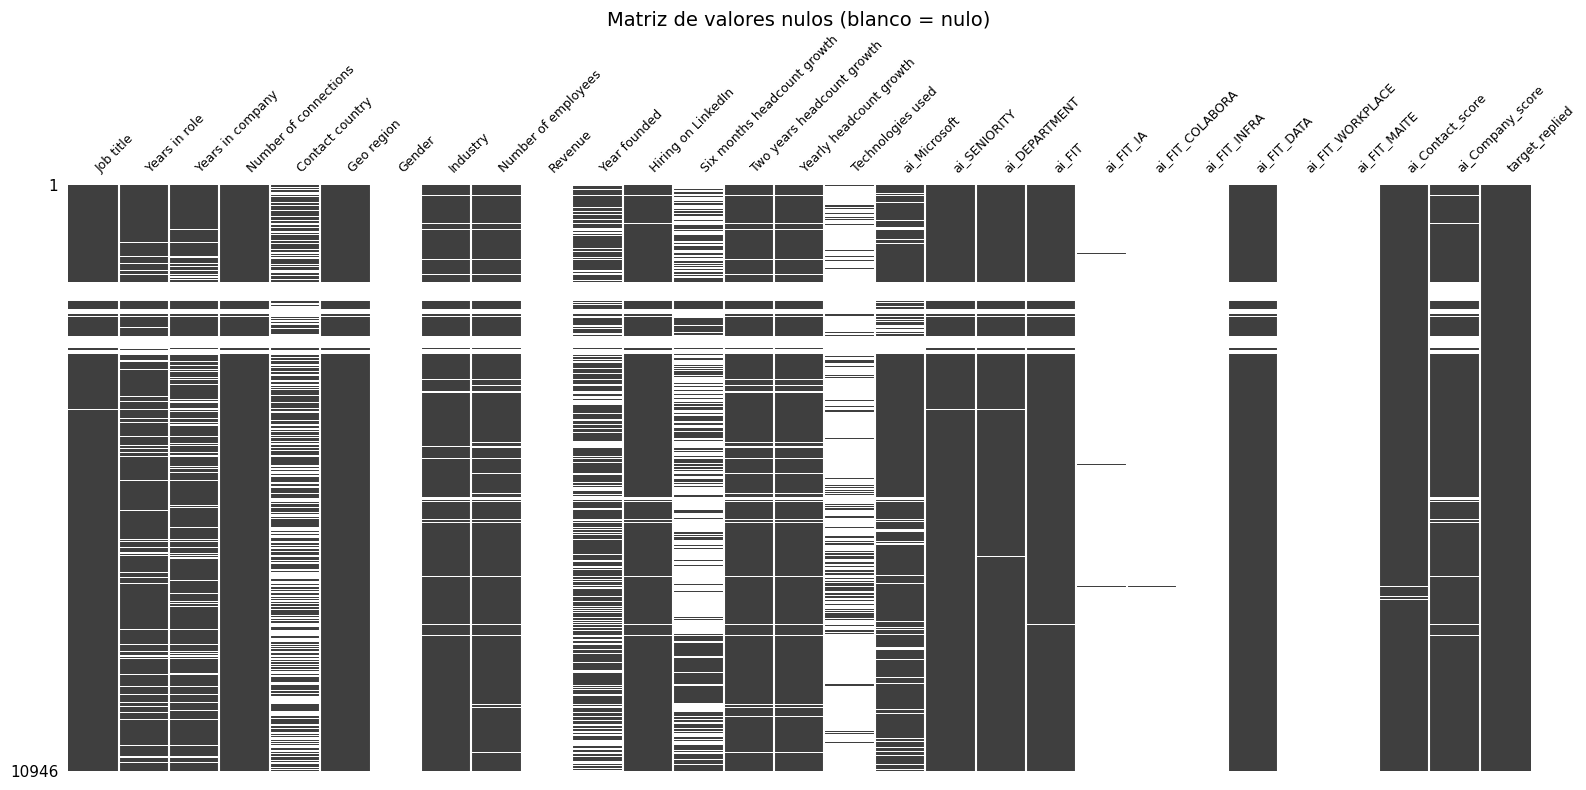

In [13]:
# 2. Visualizacion de nulos con missingno
import missingno as msno
import matplotlib.pyplot as plt

# Seleccionar columnas de features (excluir IDs, texto largo, y targets)
feature_cols = [
    'Job title', 'Years in role', 'Years in company', 'Number of connections',
    'Contact country', 'Geo region', 'Gender',
    'Industry', 'Number of employees', 'Revenue', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    'Technologies used', 'ai_Microsoft',
    'ai_SENIORITY', 'ai_DEPARTMENT',
    'ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA', 'ai_FIT_INFRA',
    'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE',
    'ai_Contact_score', 'ai_Company_score',
    'target_replied',
]
existing_feature_cols = [c for c in feature_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(16, 8))
msno.matrix(df[existing_feature_cols], ax=ax, fontsize=9, sparkline=False)
plt.title('Matriz de valores nulos (blanco = nulo)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# 3. Valores unicos de columnas categoricas clave
cat_cols = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_Contact_score', 'ai_Company_score',
            'Contact country', 'Gender']

for col in cat_cols:
    if col in df.columns and df[col].notna().any():
        print(f'\n=== {col} (top 10) ===')
        print(df[col].value_counts().head(10))


=== ai_SENIORITY (top 10) ===
ai_SENIORITY
DIRECTOR    2988
LEAD        1953
JR          1869
MANAGER     1473
CLEVEL      1251
OWNER        360
OTHER        180
VP            83
TRAINEE       18
Name: count, dtype: int64

=== ai_DEPARTMENT (top 10) ===
ai_DEPARTMENT
IT             3763
OPerations     2179
Other          2078
Sales & MKT    1292
Finance         842
Name: count, dtype: int64

=== ai_Contact_score (top 10) ===
ai_Contact_score
Disqualified    4033
High            3147
Medium          1418
Low             1266
Missing Data    1037
Name: count, dtype: int64

=== ai_Company_score (top 10) ===
ai_Company_score
High            4679
Medium          2368
Low             2237
Missing Data     540
Disqualified     140
Name: count, dtype: int64

=== Contact country (top 10) ===
Contact country
Spain         5909
España           7
Chile            6
Mexico           6
Peru             4
Portugal         4
Montserrat       3
France           3
Argentina        2
Brazil           2

In [15]:
# 4. Estadisticas de columnas numericas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir targets y binarias
numeric_stats = [c for c in numeric_cols if not c.startswith('target_')]
if numeric_stats:
    print('=== Estadisticas numericas ===')
    print(df[numeric_stats].describe().round(2).to_string())

=== Estadisticas numericas ===
       Years in company  Years in role  Number of connections  Gender   Company URN  Number of employees  Year founded  Hiring on LinkedIn  Jobs posted from LinkedIn  Revenue  Six months headcount growth  Two years headcount growth  Yearly headcount growth  ai_Microsoft  ai_FIT_WORKPLACE  ai_FIT_INFRA  ai_FIT_MAITE
count           8565.00        9020.00               10169.00     0.0  9.777000e+03              9607.00       6996.00             9964.00                        0.0      0.0                      4804.00                     9588.00                  9588.00       9334.00               0.0           0.0           0.0
mean               9.24           5.90                1184.32     NaN  1.216979e+07              2470.87       1960.89                0.41                        NaN      NaN                         1.60                       17.22                     6.37          0.74               NaN           NaN           NaN
std               

In [16]:
# 5. Distribucion del target
print('=== Distribucion del target ===')
print(f'target_replied = 0 (no respondio): {(df["target_replied"] == 0).sum():,} ({(df["target_replied"] == 0).mean():.1%})')
print(f'target_replied = 1 (respondio):    {(df["target_replied"] == 1).sum():,} ({(df["target_replied"] == 1).mean():.1%})')
print(f'\nPor canal:')
print(f'  LinkedIn: {df["target_replied_linkedin"].sum()} ({df["target_replied_linkedin"].mean():.1%})')
print(f'  Email:    {df["target_replied_email"].sum()} ({df["target_replied_email"].mean():.1%})')

=== Distribucion del target ===
target_replied = 0 (no respondio): 10,081 (92.1%)
target_replied = 1 (respondio):    865 (7.9%)

Por canal:
  LinkedIn: 552 (5.0%)
  Email:    313 (2.9%)


---
## 1.7 Seleccionar columnas finales

Organizamos las columnas por categoria y eliminamos las que ya no necesitamos.

In [17]:
# Definir columnas finales por categoria
cols_id = ['LinkedIn profile ID', 'Company URN', 'Company name',
           'First name', 'Last name', 'Full name']

cols_campaign = ['Campaigns', 'Campaign engagement status']

cols_raw_contact = [
    'Job title', 'Years in role', 'Years in company',
    'Number of connections', 'Contact country', 'Geo region',
    'Gender', 'Profile bio', 'Professional email',
]

cols_raw_company = [
    'Industry', 'Number of employees', 'Revenue', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
]

cols_tech = ['Technologies used']

cols_linkedin_activity = ['Last LinkedIn post date', 'Jobs posted from LinkedIn']

cols_ai = [
    'ai_SENIORITY', 'ai_DEPARTMENT',
    'ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA',
    'ai_FIT_INFRA', 'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE',
    'ai_Contact_score', 'ai_Company_score', 'ai_Microsoft',
]

cols_text_nlp = ['ai_CONTACT_REPORT', 'ai_COMPANY_REPORT', 'ai_MOMENTUM']

cols_engagement = ['Conversation tags']

cols_target = ['target_replied', 'target_replied_linkedin', 'target_replied_email']

# Todas las columnas en orden
all_cols = (cols_id + cols_campaign + cols_raw_contact + cols_raw_company +
            cols_tech + cols_linkedin_activity + cols_ai + cols_text_nlp +
            cols_engagement + cols_target)

# Verificar que todas existen
missing_cols = [c for c in all_cols if c not in df.columns]
if missing_cols:
    print(f'ATENCION: Columnas no encontradas: {missing_cols}')
else:
    print(f'Todas las {len(all_cols)} columnas encontradas')

# Seleccionar y reordenar
existing_cols = [c for c in all_cols if c in df.columns]
df = df[existing_cols]
print(f'\nDataset final: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Todas las 47 columnas encontradas

Dataset final: 10,946 filas x 47 columnas


---
## 1.8 Diccionario de datos

Referencia completa de cada columna, su nombre original, tipo y origen.

In [18]:
data_dict = [
    # IDs
    ('LinkedIn profile ID', 'LinkedIn profile ID', 'ID', 'Raw', 'Identificador unico del contacto en LinkedIn'),
    ('Company URN', 'Company URN', 'ID', 'Raw', 'Identificador LinkedIn de la empresa'),
    ('Company name', 'Company name', 'ID', 'Raw', 'Nombre de la empresa'),
    ('First name', 'First name', 'text', 'Raw', 'Nombre del contacto'),
    ('Last name', 'Last name', 'text', 'Raw', 'Apellido del contacto'),
    ('Full name', 'Full name', 'text', 'Raw', 'Nombre completo'),
    # Campaign
    ('Campaigns', 'Campaigns', 'text', 'Raw', 'Lista de campanas en las que participo el contacto'),
    ('Campaign engagement status', 'Campaign engagement status', 'categorical', 'Raw', 'Estado de engagement (Replied/Sent/Added)'),
    # Raw contact
    ('Job title', 'Job title', 'text', 'Raw', 'Titulo profesional en LinkedIn'),
    ('Years in role', 'Years in role', 'numeric', 'Raw', 'Anos en el puesto actual'),
    ('Years in company', 'Years in company', 'numeric', 'Raw', 'Anos en la empresa actual'),
    ('Number of connections', 'Number of connections', 'numeric', 'Raw', 'Numero de conexiones LinkedIn'),
    ('Contact country', 'Contact country', 'categorical', 'Raw', 'Pais del contacto'),
    ('Geo region', 'Geo region', 'categorical', 'Raw', 'Region geografica'),
    ('Gender', 'Gender', 'categorical', 'Raw', 'Genero'),
    ('Profile bio', 'Profile bio', 'text', 'Raw', 'Biografia LinkedIn'),
    ('Professional email', 'Professional email', 'text', 'Raw', 'Email profesional (para feature binaria has_email)'),
    # Raw company
    ('Industry', 'Industry', 'categorical', 'Raw', 'Sector de la empresa'),
    ('Number of employees', 'Number of employees', 'numeric', 'Raw', 'Numero de empleados'),
    ('Revenue', 'Revenue', 'numeric', 'Raw', 'Facturacion'),
    ('Year founded', 'Year founded', 'numeric', 'Raw', 'Ano de fundacion'),
    ('Hiring on LinkedIn', 'Hiring on LinkedIn', 'binary', 'Raw', 'Si la empresa esta contratando en LinkedIn'),
    ('Six months headcount growth', 'Six months headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla 6 meses (%)'),
    ('Two years headcount growth', 'Two years headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla 2 anos (%)'),
    ('Yearly headcount growth', 'Yearly headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla anual (%)'),
    # Tech
    ('Technologies used', 'Technologies used', 'text', 'Raw', 'Lista de tecnologias que usa la empresa'),
    # LinkedIn activity
    ('Last LinkedIn post date', 'Last LinkedIn post date', 'datetime', 'Raw', 'Fecha del ultimo post en LinkedIn'),
    ('Jobs posted from LinkedIn', 'Jobs posted from LinkedIn', 'numeric', 'Raw', 'Numero de ofertas publicadas en LinkedIn'),
    # AI-enriched
    ('ai_SENIORITY', 'SENIORITY', 'categorical', 'AI-enriched', 'Nivel jerarquico (C-Level, Director, Manager, etc.)'),
    ('ai_DEPARTMENT', 'DEPARTMENT', 'categorical', 'AI-enriched', 'Departamento (IT, Operations, HR, etc.)'),
    ('ai_FIT', 'FIT', 'categorical', 'AI-enriched', 'Puntuacion general de fit'),
    ('ai_FIT_IA', 'FIT IA', 'categorical', 'AI-enriched', 'Fit para Soluciones AI (Azure AI, Copilot)'),
    ('ai_FIT_COLABORA', 'FIT COLABORA', 'categorical', 'AI-enriched', 'Fit para Collaboration Hub (Teams, SharePoint)'),
    ('ai_FIT_INFRA', 'FIT INFRA', 'categorical', 'AI-enriched', 'Fit para Infraestructuras Cloud (Azure)'),
    ('ai_FIT_DATA', 'FIT DATA', 'categorical', 'AI-enriched', 'Fit para Data Analytics (Power BI, Fabric)'),
    ('ai_FIT_WORKPLACE', 'FIT WORKPLACE', 'categorical', 'AI-enriched', 'Fit para Digital Workplace (M365)'),
    ('ai_FIT_MAITE', 'FIT MAITE', 'categorical', 'AI-enriched', 'Fit para Gobernanza IT (Intune, Entra ID, Purview)'),
    ('ai_Contact_score', 'Contact score', 'categorical', 'AI-enriched', 'Puntuacion del contacto por IA'),
    ('ai_Company_score', 'Company score', 'categorical', 'AI-enriched', 'Puntuacion de la empresa por IA'),
    ('ai_Microsoft', 'Microsoft?', 'categorical', 'AI-enriched', 'Si la empresa usa tecnologia Microsoft'),
    # NLP text
    ('ai_CONTACT_REPORT', 'CONTACT REPORT', 'text', 'AI-enriched', 'Informe IA sobre el perfil del contacto'),
    ('ai_COMPANY_REPORT', 'COMPANY REPORT', 'text', 'AI-enriched', 'Informe IA sobre la empresa'),
    ('ai_MOMENTUM', 'MOMENTUM', 'text', 'AI-enriched', 'Senales de timing (por que contactar ahora)'),
    # Engagement
    ('Conversation tags', 'Conversation tags', 'categorical', 'Raw', 'Etiquetas de la conversacion'),
    # Targets
    ('target_replied', '-', 'binary', 'Created', 'Variable objetivo: 1 si respondio, 0 si no'),
    ('target_replied_linkedin', '-', 'binary', 'Created', '1 si respondio por LinkedIn'),
    ('target_replied_email', '-', 'binary', 'Created', '1 si respondio por email'),
]

dict_df = pd.DataFrame(data_dict, columns=['Columna', 'Nombre original', 'Tipo', 'Origen', 'Descripcion'])
print(f'Diccionario de datos: {len(dict_df)} columnas documentadas')
dict_df

Diccionario de datos: 47 columnas documentadas


,Columna,Nombre original,Tipo,Origen,Descripcion
0,LinkedIn profile ID,LinkedIn profile ID,ID,Raw,Identificador unico del contacto en LinkedIn
1,Company URN,Company URN,ID,Raw,Identificador LinkedIn de la empresa
2,Company name,Company name,ID,Raw,Nombre de la empresa
3,First name,First name,text,Raw,Nombre del contacto
4,Last name,Last name,text,Raw,Apellido del contacto
5,Full name,Full name,text,Raw,Nombre completo
6,Campaigns,Campaigns,text,Raw,Lista de campanas en las que participo el cont...
7,Campaign engagement status,Campaign engagement status,categorical,Raw,Estado de engagement (Replied/Sent/Added)
8,Job title,Job title,text,Raw,Titulo profesional en LinkedIn
9,Years in role,Years in role,numeric,Raw,Anos en el puesto actual


---
## 1.9 Guardar outputs

Guardamos los datasets en formato **Parquet** (formato binario columnar):
- 10x mas compacto que CSV
- 10x mas rapido de cargar
- Preserva tipos de datos

In [19]:
# 1. Dataset de modelado
output_path = os.path.join(WORKING_DATA, 'modeling_dataset_raw.parquet')
df.to_parquet(output_path, index=False)
file_size = os.path.getsize(output_path) / 1e6
print(f'Guardado: modeling_dataset_raw.parquet')
print(f'  Tamano: {file_size:.1f} MB')
print(f'  Forma: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Guardado: modeling_dataset_raw.parquet
  Tamano: 37.5 MB
  Forma: 10,946 filas x 47 columnas


In [20]:
# 2. Conversation level analytics (para analisis de funnel/timing en NB02)
analytics = pd.read_csv(
    os.path.join(RAW_DATA, 'conversation_level_analytics_ES.csv'),
    encoding='utf-8-sig'
)
analytics['firstMessageAt'] = pd.to_datetime(analytics['firstMessageAt'])
analytics_path = os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet')
analytics.to_parquet(analytics_path, index=False)
print(f'Guardado: conversation_analytics_ES.parquet ({len(analytics):,} filas)')

# 3. Daily analytics
daily = pd.read_csv(
    os.path.join(RAW_DATA, 'daily_comprehensive_analytics_ES.csv'),
    encoding='utf-8-sig'
)
daily['date'] = pd.to_datetime(daily['date'])
daily_path = os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet')
daily.to_parquet(daily_path, index=False)
print(f'Guardado: daily_analytics_ES.parquet ({len(daily)} filas)')

# 4. Replies analytics
replies = pd.read_csv(
    os.path.join(RAW_DATA, 'replies_analytics_ES.csv'),
    encoding='utf-8-sig'
)
replies['timestamp'] = pd.to_datetime(replies['timestamp'])
replies_path = os.path.join(WORKING_DATA, 'replies_analytics_ES.parquet')
replies.to_parquet(replies_path, index=False)
print(f'Guardado: replies_analytics_ES.parquet ({len(replies)} filas)')

Guardado: conversation_analytics_ES.parquet (11,517 filas)
Guardado: daily_analytics_ES.parquet (310 filas)
Guardado: replies_analytics_ES.parquet (13 filas)


---
## Resumen

### Que hemos hecho:
1. Cargado `contacts_table_ES.csv` como tabla base (11,095 contactos unicos, 45 de 373 columnas)
2. Creado la variable objetivo `target_replied` desde `Campaign engagement status`
3. Eliminado duplicados de LinkedIn profile ID
4. Renombrado columnas AI con prefijo `ai_` para trazabilidad
5. Convertido tipos de datos (numericos, fechas)
6. Verificado calidad: nulos, duplicados, distribucion del target
7. Construido diccionario de datos
8. Guardado en formato Parquet (modelado + analytics + daily + replies)

### Decision arquitectural: contacts_table como tabla base
- `conversation_level_analytics` usa un `contactId` interno de HeyReach que no existe en la tabla de contactos
- `contacts_table_ES` contiene tanto las features como la informacion de engagement en una sola tabla
- La granularidad contacto (vs conversacion) es mas adecuada para predecir QUIEN contactar
- Los datos de conversacion se guardan por separado para analisis de funnel y timing

### Que NO hemos hecho (se hara en notebooks posteriores):
- Feature engineering (NB03)
- NLP sobre campos de texto (NB03)
- Enrichment externo (NB03)
- Imputacion de nulos (NB03)
- Modelado (NB04)

### Proximo paso: NB02 - Analisis Exploratorio de Datos

In [21]:
# Resumen final
print('=' * 60)
print('RESUMEN NOTEBOOK 01')
print('=' * 60)
print(f'Dataset de modelado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'  Positivos (target=1): {df["target_replied"].sum():,} ({df["target_replied"].mean():.1%})')
print(f'  Negativos (target=0): {(df["target_replied"]==0).sum():,} ({(df["target_replied"]==0).mean():.1%})')
print(f'\nColumnas por origen:')
print(f'  IDs:            {len(cols_id)}')
print(f'  Campaign info:  {len(cols_campaign)}')
print(f'  Raw contact:    {len(cols_raw_contact)}')
print(f'  Raw company:    {len(cols_raw_company)}')
print(f'  Tech:           {len(cols_tech)}')
print(f'  LinkedIn act.:  {len(cols_linkedin_activity)}')
print(f'  AI-enriched:    {len(cols_ai)}')
print(f'  Text (NLP):     {len(cols_text_nlp)}')
print(f'  Engagement:     {len(cols_engagement)}')
print(f'  Targets:        {len(cols_target)}')
print(f'\nArchivos generados:')
for f in sorted(os.listdir(WORKING_DATA)):
    fpath = os.path.join(WORKING_DATA, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f'  {f}: {size:.1f} MB')

RESUMEN NOTEBOOK 01
Dataset de modelado: 10,946 filas x 47 columnas
  Positivos (target=1): 865 (7.9%)
  Negativos (target=0): 10,081 (92.1%)

Columnas por origen:
  IDs:            6
  Campaign info:  2
  Raw contact:    9
  Raw company:    8
  Tech:           1
  LinkedIn act.:  2
  AI-enriched:    12
  Text (NLP):     3
  Engagement:     1
  Targets:        3

Archivos generados:
  conversation_analytics_ES.parquet: 0.3 MB
  daily_analytics_ES.parquet: 0.0 MB
  modeling_dataset_raw.parquet: 37.5 MB
  replies_analytics_ES.parquet: 0.0 MB
